# Preprocessing EEG con MNE, ICA Picard e ICLabel

Questo notebook esegue il preprocessing del dataset EEG ADHD soggetto per soggetto.

## Pipeline

1. lettura del CSV;
2. conversione dei nomi storici `T3/T4/T5/T6` in `T7/T8/P7/P8`;
3. conversione da µV a V;
4. assegnazione del montaggio standard 10–20;
5. filtro passa-banda 1–45 Hz;
6. riferimento medio comune;
7. ICA Picard;
8. classificazione automatica delle componenti con ICLabel;
9. rimozione delle componenti classificate come oculari con probabilità almeno pari a 0.90;
10. ricostruzione del segnale e salvataggio in µV.

## Regola di esclusione

Una componente viene rimossa se:

- l'etichetta prevista da ICLabel è `eye blink`;
- la probabilità associata all'etichetta prevista è ≥ 0.90.

Non viene imposto un numero massimo di componenti rimosse. Le componenti muscolari non vengono eliminate automaticamente.

## Nota metodologica

ICLabel è stato sviluppato principalmente su componenti ottenute con ICA Picard, riferimento medio comune e dati filtrati fino a frequenze superiori a quelle disponibili in questo dataset.

Poiché il dataset è campionato a 128 Hz, la frequenza di Nyquist è 64 Hz. Nel progetto viene quindi utilizzato un filtro 1–45 Hz. Questa differenza rispetto alle condizioni originarie di sviluppo di ICLabel deve essere dichiarata come limitazione.


## Uniformazione della durata

Per ciascun soggetto vengono esclusi i primi 2 secondi di assestamento e vengono utilizzati i successivi 60 secondi, corrispondenti all'intervallo comune 2–62 s. Il taglio viene applicato prima del filtro, dell'ICA e di ICLabel.


## 1. Installazione facoltativa

In [53]:
# Eseguire soltanto se necessario, poi riavviare il kernel.
# %pip install -U mne mne-icalabel torch pandas numpy matplotlib scipy

## 2. Import

In [54]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

from mne.preprocessing import ICA
from mne_icalabel import label_components

import mne_icalabel

print('MNE:', mne.__version__)
print('MNE-ICALabel:', mne_icalabel.__version__)

mne.set_log_level('WARNING')

MNE: 1.12.1
MNE-ICALabel: 0.9.0


## 3. Configurazione

In [55]:
INPUT_CSV = Path('data/adhdata.csv')

OUTPUT_DIR = Path('outputs/preprocessing_iclabel')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_CSV = OUTPUT_DIR / 'adhdata_preprocessed_1_45Hz_ICA_ICLabel.csv'
REPORT_CSV = OUTPUT_DIR / 'iclabel_component_report.csv'
SUBJECT_SUMMARY_CSV = OUTPUT_DIR / 'iclabel_subject_summary.csv'
SUMMARY_JSON = OUTPUT_DIR / 'preprocessing_summary.json'

SFREQ = 128.0
START_OFFSET_SEC = 2.0
COMMON_DURATION_SEC = 60.0

EEG_CHANNELS = [
    'Fz', 'Cz', 'Pz',
    'C3', 'T7', 'C4', 'T8',
    'Fp1', 'Fp2',
    'F3', 'F4', 'F7', 'F8',
    'P3', 'P4', 'P7', 'P8',
    'O1', 'O2',
]

ID_COLUMN = 'ID'
CLASS_COLUMN = 'Class'

L_FREQ = 1.0
H_FREQ = 45.0
APPLY_AVERAGE_REFERENCE = True

ICA_N_COMPONENTS = 0.95
ICA_RANDOM_STATE = 42
ICA_MAX_ITER = 3000

EYE_THRESHOLD = 0.90
REMOVE_MUSCLE = False
MUSCLE_THRESHOLD = 0.95

SAVE_ICA_MODELS = False
ICA_DIR = OUTPUT_DIR / 'ica_models'
if SAVE_ICA_MODELS:
    ICA_DIR.mkdir(parents=True, exist_ok=True)

# None = tutti i soggetti; 
N_SUBJECTS_TEST = None

## 4. Funzioni

I nomi dei canali vengono normalizzati una sola volta subito dopo la lettura del CSV. Da quel momento il notebook usa sempre `T7`, `T8`, `P7`, `P8`, senza ulteriori rinomine dentro gli oggetti MNE.

In [56]:
COLUMN_RENAME = {
    'T3': 'T7',
    'T4': 'T8',
    'T5': 'P7',
    'T6': 'P8',
}


def validate_input_dataframe(df: pd.DataFrame) -> None:
    required_columns = EEG_CHANNELS + [CLASS_COLUMN, ID_COLUMN]
    missing_columns = [c for c in required_columns if c not in df.columns]
    if missing_columns:
        raise ValueError('Colonne mancanti dopo la normalizzazione: ' + ', '.join(missing_columns))

    eeg_values = df[EEG_CHANNELS].to_numpy(dtype=float)
    if np.isnan(eeg_values).any():
        raise ValueError('Sono presenti NaN nei canali EEG.')
    if not np.isfinite(eeg_values).all():
        raise ValueError('Sono presenti valori EEG non finiti.')

    nyquist = SFREQ / 2
    if H_FREQ >= nyquist:
        raise ValueError(f'H_FREQ={H_FREQ} Hz deve essere inferiore a Nyquist={nyquist} Hz.')


def create_subject_raw(subject_df: pd.DataFrame) -> mne.io.RawArray:
    eeg_uv = subject_df[EEG_CHANNELS].to_numpy(dtype=float).T
    eeg_v = eeg_uv * 1e-6

    info = mne.create_info(
        ch_names=EEG_CHANNELS,
        sfreq=SFREQ,
        ch_types=['eeg'] * len(EEG_CHANNELS),
    )

    raw = mne.io.RawArray(eeg_v, info, verbose=False)
    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage, on_missing='raise', verbose=False)
    return raw


def crop_to_common_duration(
    raw: mne.io.BaseRaw,
    subject_id=None,
) -> mne.io.BaseRaw:
    """
    Esclude i primi START_OFFSET_SEC secondi e mantiene
    esattamente i successivi COMMON_DURATION_SEC secondi.
    """
    start_sample = int(round(START_OFFSET_SEC * SFREQ))
    required_samples = int(round(COMMON_DURATION_SEC * SFREQ))
    stop_sample = start_sample + required_samples

    available_samples = int(raw.n_times)
    minimum_required_duration = START_OFFSET_SEC + COMMON_DURATION_SEC

    if available_samples < stop_sample:
        available_duration = available_samples / SFREQ
        raise ValueError(
            f"Soggetto {subject_id}: durata insufficiente. "
            f"Disponibili {available_duration:.3f} s, "
            f"richiesti almeno {minimum_required_duration:.3f} s."
        )

    data = raw.get_data(start=start_sample, stop=stop_sample)

    cropped = mne.io.RawArray(
        data,
        raw.info.copy(),
        first_samp=0,
        verbose=False,
    )

    if cropped.n_times != required_samples:
        raise RuntimeError(
            "Numero di campioni dopo il taglio non corretto: "
            f"{cropped.n_times}; attesi {required_samples}."
        )

    return cropped


def preprocess_for_ica(raw: mne.io.BaseRaw) -> mne.io.BaseRaw:
    raw_filtered = raw.copy().filter(
        l_freq=L_FREQ,
        h_freq=H_FREQ,
        method='fir',
        phase='zero',
        fir_design='firwin',
        verbose=False,
    )

    if APPLY_AVERAGE_REFERENCE:
        raw_filtered.set_eeg_reference(
            ref_channels='average',
            projection=False,
            verbose=False,
        )
    return raw_filtered


# def fit_extended_infomax(
#     raw_filtered: mne.io.BaseRaw,
# ) -> tuple[ICA, bool]:

#     ica = ICA(
#         n_components=ICA_N_COMPONENTS,
#         method="infomax",
#         fit_params={
#             "extended": True,
#         },
#         random_state=ICA_RANDOM_STATE,
#         max_iter=ICA_MAX_ITER,
#     )

#     ica.fit(
#         raw_filtered,
#         picks="eeg",
#         reject_by_annotation=True,
#         verbose=False,
#     )

#     n_iterations = int(ica.n_iter_)

#     converged = (
#         n_iterations < ICA_MAX_ITER
#     )

#     if not converged:
#         print(
#             "ATTENZIONE: ICA arrivata al limite di "
#             f"{ICA_MAX_ITER} iterazioni."
#         )

#     return ica, converged

def fit_picard_extended_infomax(
    raw_filtered: mne.io.BaseRaw,
) -> tuple[ICA, bool]:

    ica = ICA(
        n_components=ICA_N_COMPONENTS, 
        method="picard",                # <-- Cambia il metodo in 'picard'
        fit_params={
            "ortho": False,             # <-- Forza la soluzione di tipo Infomax
            "extended": True,           # <-- Attiva la versione Extended per sorgenti sub/super-Gaussiane
        },
        random_state=ICA_RANDOM_STATE,
        max_iter=ICA_MAX_ITER,
    )

    ica.fit(
        raw_filtered,
        picks="eeg",
        reject_by_annotation=True,
        verbose=False,
    )

    n_iterations = int(ica.n_iter_)
    converged = n_iterations < ICA_MAX_ITER

    if not converged:
        print(
            "ATTENZIONE: ICA arrivata al limite di "
            f"{ICA_MAX_ITER} iterazioni."
        )

    return ica, converged


def classify_and_select_components(raw_filtered: mne.io.BaseRaw, ica: ICA) -> dict:
    iclabel_output = label_components(raw_filtered, ica, method='iclabel')

    predicted_labels = list(iclabel_output['labels'])
    predicted_confidences = np.asarray(iclabel_output['y_pred_proba'], dtype=float)

    expected_length = int(ica.n_components_)
    if len(predicted_labels) != expected_length:
        raise RuntimeError('Numero di etichette ICLabel non coerente con il numero di componenti ICA.')
    if predicted_confidences.shape != (expected_length,):
        raise RuntimeError(
            f'Shape delle probabilità ICLabel inattesa: {predicted_confidences.shape}; '
            f'attesa {(expected_length,)}.'
        )

    eye_to_remove = [
        idx
        for idx, (label, confidence) in enumerate(zip(predicted_labels, predicted_confidences))
        if label == 'eye blink' and confidence >= EYE_THRESHOLD
    ]

    muscle_to_remove = []
    if REMOVE_MUSCLE:
        muscle_to_remove = [
            idx
            for idx, (label, confidence) in enumerate(zip(predicted_labels, predicted_confidences))
            if label == 'muscle artifact' and confidence >= MUSCLE_THRESHOLD
        ]

    components_to_remove = sorted(set(eye_to_remove + muscle_to_remove))

    return {
        'predicted_labels': predicted_labels,
        'predicted_confidences': predicted_confidences,
        'eye_to_remove': eye_to_remove,
        'muscle_to_remove': muscle_to_remove,
        'components_to_remove': components_to_remove,
    }


def raw_to_dataframe(raw_clean: mne.io.BaseRaw, subject_df: pd.DataFrame) -> pd.DataFrame:
    eeg_uv = raw_clean.get_data(picks=EEG_CHANNELS).T * 1e6
    clean_df = pd.DataFrame(eeg_uv, columns=EEG_CHANNELS)
    clean_df[CLASS_COLUMN] = subject_df[CLASS_COLUMN].to_numpy()
    clean_df[ID_COLUMN] = subject_df[ID_COLUMN].to_numpy()
    return clean_df[subject_df.columns.tolist()]

## 5. Lettura e controllo del dataset

In [57]:
df = pd.read_csv(INPUT_CSV)
df = df.rename(columns=COLUMN_RENAME)
validate_input_dataframe(df)

subject_ids = df[ID_COLUMN].drop_duplicates().tolist()
if N_SUBJECTS_TEST is not None:
    subject_ids = subject_ids[:N_SUBJECTS_TEST]

print('Shape:', df.shape)
print('Soggetti da elaborare:', len(subject_ids))
print('Colonne:', df.columns.tolist())

Shape: (2166383, 21)
Soggetti da elaborare: 121
Colonne: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz', 'Class', 'ID']


## 6. Controllo preliminare su un soggetto

In [58]:
SUBJECT_TO_INSPECT = subject_ids[0]
subject_df = df.loc[df[ID_COLUMN] == SUBJECT_TO_INSPECT].copy()

raw_full = create_subject_raw(
    subject_df
)

raw = crop_to_common_duration(
    raw_full,
    subject_id=SUBJECT_TO_INSPECT,
)

raw_filtered = preprocess_for_ica(
    raw
)
ica, ica_converged = fit_picard_extended_infomax(raw_filtered)
selection = classify_and_select_components(raw_filtered, ica)

inspection_table = pd.DataFrame({
    'component': np.arange(ica.n_components_),
    'predicted_label': selection['predicted_labels'],
    'predicted_confidence': selection['predicted_confidences'],
    'will_be_removed': [
        idx in selection['components_to_remove']
        for idx in range(ica.n_components_)
    ],
})

print('Soggetto:', SUBJECT_TO_INSPECT)
print('Numero componenti ICA:', ica.n_components_)
print('ICA convergente:', ica_converged)
print('Iterazioni ICA:', ica.n_iter_)
print('Componenti da rimuovere:', selection['components_to_remove'])

display(
    inspection_table.sort_values(
        by=['will_be_removed', 'predicted_confidence'],
        ascending=[False, False],
    )
)

C:\Users\noemi\AppData\Local\Temp\ipykernel_2136\2830678455.py:172: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  iclabel_output = label_components(raw_filtered, ica, method='iclabel')


Soggetto: v10p
Numero componenti ICA: 14
ICA convergente: True
Iterazioni ICA: 50
Componenti da rimuovere: [0]


,component,predicted_label,predicted_confidence,will_be_removed
0,0,eye blink,0.980176,True
10,10,brain,0.983650,False
7,7,line noise,0.977819,False
2,2,brain,0.973668,False
5,5,line noise,0.937503,False
8,8,brain,0.927354,False
1,1,line noise,0.803379,False
13,13,brain,0.784504,False
9,9,brain,0.773608,False
11,11,brain,0.673180,False


### Controllo visivo facoltativo

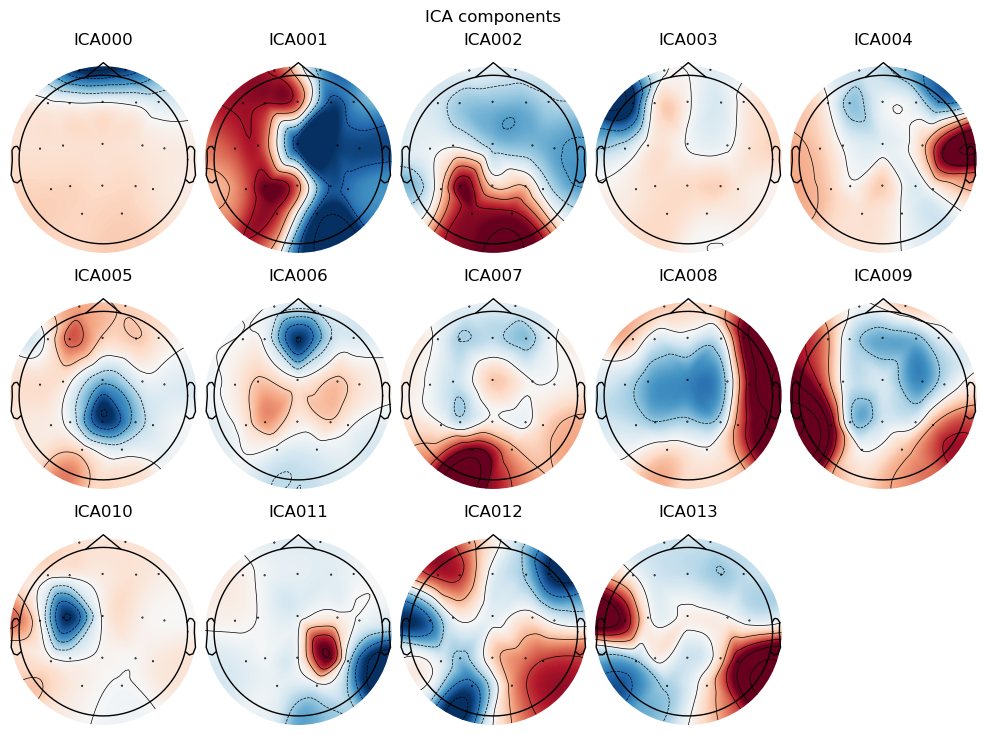

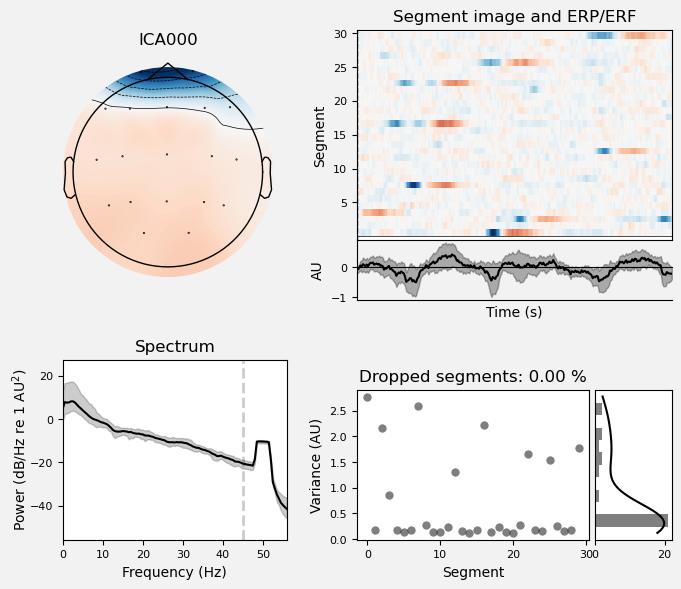

In [59]:
ica.plot_components(show=True)

if selection['components_to_remove']:
    ica.plot_properties(
        raw_filtered,
        picks=selection['components_to_remove'],
        show=True,
    )
else:
    print('Nessuna componente supera la soglia di esclusione.')

## 7. Elaborazione automatica di tutti i soggetti

In [60]:
clean_subjects = []
component_report_rows = []
subject_summary_rows = []

for position, subject_id in enumerate(subject_ids, start=1):
    subject_df = df.loc[
        df[ID_COLUMN] == subject_id
    ].copy()

    print(
        f'[{position:03d}/{len(subject_ids):03d}] '
        f'Soggetto {subject_id}'
    )

    # Registrazione completa del soggetto
    raw_full = create_subject_raw(
        subject_df
    )

    original_n_samples = int(
        raw_full.n_times
    )

    original_duration_sec = float(
        original_n_samples / SFREQ
    )

    # Selezione dell'intervallo comune 5–65 secondi
    raw = crop_to_common_duration(
        raw_full,
        subject_id=subject_id,
    )

    # Selezione dello stesso intervallo anche nel DataFrame
    start_sample = int(
        round(START_OFFSET_SEC * SFREQ)
    )

    required_samples = int(
        round(COMMON_DURATION_SEC * SFREQ)
    )

    stop_sample = (
        start_sample
        + required_samples
    )

    subject_segment_df = (
        subject_df
        .iloc[start_sample:stop_sample]
        .reset_index(drop=True)
    )

    # Controllo di sicurezza
    if len(subject_segment_df) != required_samples:
        raise RuntimeError(
            f'Soggetto {subject_id}: '
            f'il DataFrame contiene '
            f'{len(subject_segment_df)} campioni, '
            f'ma ne erano attesi {required_samples}.'
        )

    # Preprocessing del segmento 5–65 s
    raw_filtered = preprocess_for_ica(
        raw
    )

    ica, ica_converged = (
        fit_picard_extended_infomax(
            raw_filtered
        )
    )

    print(
    "Componenti ICA:",
    ica.n_components_,
    "| Iterazioni:",
    ica.n_iter_,
    )

    selection = (
        classify_and_select_components(
            raw_filtered,
            ica,
        )
    )

    components_to_remove = selection[
        'components_to_remove'
    ]

    # Report di tutte le componenti ICA
    for component_idx in range(
        ica.n_components_
    ):
        component_report_rows.append({
            ID_COLUMN: subject_id,
            CLASS_COLUMN: subject_df[
                CLASS_COLUMN
            ].iloc[0],
            'component': int(
                component_idx
            ),
            'predicted_label': selection[
                'predicted_labels'
            ][component_idx],
            'predicted_confidence': float(
                selection[
                    'predicted_confidences'
                ][component_idx]
            ),
            'removed': bool(
                component_idx
                in components_to_remove
            ),
        })

    # Ricostruzione del segnale pulito
    raw_clean = raw_filtered.copy()

    ica.apply(
        raw_clean,
        exclude=components_to_remove,
        verbose=False,
    )

    # Conversione in DataFrame usando Class e ID
    # dello stesso segmento 5–65 s
    clean_subjects.append(
        raw_to_dataframe(
            raw_clean,
            subject_segment_df,
        )
    )

    eye_confidences = [
        float(confidence)
        for label, confidence in zip(
            selection['predicted_labels'],
            selection['predicted_confidences'],
        )
        if label == 'eye blink'
    ]

    subject_summary_rows.append({
        ID_COLUMN: subject_id,
        CLASS_COLUMN: subject_df[
            CLASS_COLUMN
        ].iloc[0],
        'original_n_samples': (
            original_n_samples
        ),
        'original_duration_sec': (
            original_duration_sec
        ),
        'n_samples_used': int(
            raw_clean.n_times
        ),
        'duration_sec_used': float(
            raw_clean.n_times / SFREQ
        ),
        'start_offset_sec': float(
            START_OFFSET_SEC
        ),
        'end_time_sec': float(
            START_OFFSET_SEC
            + COMMON_DURATION_SEC
        ),
        'n_ica_components': int(
            ica.n_components_
        ),
        'ica_iterations': int(
            ica.n_iter_
        ),
        'ica_converged': bool(
            ica_converged
        ),
        'removed_components': ','.join(
            map(
                str,
                components_to_remove,
            )
        ),
        'n_removed': int(
            len(components_to_remove)
        ),
        'n_eye_removed': int(
            len(
                selection[
                    'eye_to_remove'
                ]
            )
        ),
        'n_muscle_removed': int(
            len(
                selection[
                    'muscle_to_remove'
                ]
            )
        ),
        'max_predicted_eye_confidence': (
            max(
                eye_confidences,
                default=0.0,
            )
        ),
    })

    if SAVE_ICA_MODELS:
        safe_subject_id = (
            str(subject_id)
            .replace('/', '_')
        )

        ica.save(
            ICA_DIR
            / f'subject_{safe_subject_id}-ica.fif',
            overwrite=True,
        )

clean_df = pd.concat(
    clean_subjects,
    ignore_index=True,
)

component_report_df = pd.DataFrame(
    component_report_rows
)

subject_summary_df = pd.DataFrame(
    subject_summary_rows
)

print('Elaborazione completata.')
print('Shape dataset pulito:', clean_df.shape)

[001/121] Soggetto v10p
Componenti ICA: 14 | Iterazioni: 50


C:\Users\noemi\AppData\Local\Temp\ipykernel_2136\2830678455.py:172: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  iclabel_output = label_components(raw_filtered, ica, method='iclabel')


[002/121] Soggetto v12p
Componenti ICA: 11 | Iterazioni: 61


C:\Users\noemi\AppData\Local\Temp\ipykernel_2136\2830678455.py:172: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  iclabel_output = label_components(raw_filtered, ica, method='iclabel')


[003/121] Soggetto v14p
Componenti ICA: 10 | Iterazioni: 80


...

[120/121] Soggetto v309
Componenti ICA: 9 | Iterazioni: 36


C:\Users\noemi\AppData\Local\Temp\ipykernel_2136\2830678455.py:172: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  iclabel_output = label_components(raw_filtered, ica, method='iclabel')


[121/121] Soggetto v310
Componenti ICA: 9 | Iterazioni: 57


C:\Users\noemi\AppData\Local\Temp\ipykernel_2136\2830678455.py:172: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  iclabel_output = label_components(raw_filtered, ica, method='iclabel')


Elaborazione completata.
Shape dataset pulito: (929280, 21)


## 8. Controlli di integrità

In [61]:

required_samples_per_subject = int(round(COMMON_DURATION_SEC * SFREQ))
expected_total_rows = len(subject_ids) * required_samples_per_subject

assert len(clean_df) == expected_total_rows
assert clean_df.columns.tolist() == df.columns.tolist()

samples_per_subject = clean_df.groupby(ID_COLUMN).size()
assert (samples_per_subject == required_samples_per_subject).all()

assert not clean_df[EEG_CHANNELS].isna().any().any()
assert np.isfinite(clean_df[EEG_CHANNELS].to_numpy()).all()

print("Tutti i controlli sono stati superati.")
print("Campioni per soggetto:", required_samples_per_subject)
print("Durata per soggetto:", required_samples_per_subject / SFREQ, "s")


Tutti i controlli sono stati superati.
Campioni per soggetto: 7680
Durata per soggetto: 60.0 s


## 9. Salvataggio

In [62]:
clean_df.to_csv(OUTPUT_CSV, index=False)
component_report_df.to_csv(REPORT_CSV, index=False)
subject_summary_df.to_csv(SUBJECT_SUMMARY_CSV, index=False)

summary = {
    'input_csv': str(INPUT_CSV),
    'output_csv': str(OUTPUT_CSV),
    'sampling_frequency_hz': float(SFREQ),
    'bandpass_hz': [float(L_FREQ), float(H_FREQ)],
    'average_reference': bool(APPLY_AVERAGE_REFERENCE),
    'ica_method': 'Picard (Extended Infomax)',
    'ica_n_components': ICA_N_COMPONENTS,
    'ica_random_state': int(ICA_RANDOM_STATE),
    'ica_max_iter': int(ICA_MAX_ITER),
    'eye_threshold': float(EYE_THRESHOLD),
    'remove_muscle': bool(REMOVE_MUSCLE),
    'muscle_threshold': float(MUSCLE_THRESHOLD),
    'n_subjects': int(len(subject_ids)),
    'n_rows': int(len(clean_df)),
    'total_removed_components': int(subject_summary_df['n_removed'].sum()),
    'subjects_with_no_removed_components': int((subject_summary_df['n_removed'] == 0).sum()),
    'subjects_with_nonconverged_ica': int((~subject_summary_df['ica_converged']).sum()),
}

with open(SUMMARY_JSON, 'w', encoding='utf-8') as file:
    json.dump(summary, file, indent=2, ensure_ascii=False)

print('File salvati:')
print('-', OUTPUT_CSV)
print('-', REPORT_CSV)
print('-', SUBJECT_SUMMARY_CSV)
print('-', SUMMARY_JSON)

File salvati:
- outputs\preprocessing_iclabel\adhdata_preprocessed_1_45Hz_ICA_ICLabel.csv
- outputs\preprocessing_iclabel\iclabel_component_report.csv
- outputs\preprocessing_iclabel\iclabel_subject_summary.csv
- outputs\preprocessing_iclabel\preprocessing_summary.json


## 10. Riepilogo della pulizia

,ID,Class,original_n_samples,original_duration_sec,n_samples_used,duration_sec_used,start_offset_sec,end_time_sec,n_ica_components,ica_iterations,ica_converged,removed_components,n_removed,n_eye_removed,n_muscle_removed,max_predicted_eye_confidence
0,v10p,ADHD,14304,111.750000,7680,60.0,2.0,62.0,14,50,True,0,1,1,0,0.980176
1,v12p,ADHD,17604,137.531250,7680,60.0,2.0,62.0,11,61,True,1,1,1,0,0.966563
2,v14p,ADHD,17562,137.203125,7680,60.0,2.0,62.0,10,80,True,0,1,1,0,0.990608
3,v15p,ADHD,43252,337.906250,7680,60.0,2.0,62.0,10,41,True,2,1,1,0,0.993620
4,v173,ADHD,24241,189.382812,7680,60.0,2.0,62.0,13,141,True,,0,0,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,v306,Control,18301,142.976562,7680,60.0,2.0,62.0,11,48,True,,0,0,0,0.464480
117,v307,Control,22807,178.179688,7680,60.0,2.0,62.0,12,76,True,1,1,1,0,0.979653
118,v308,Control,17025,133.007812,7680,60.0,2.0,62.0,11,76,True,,0,0,0,0.000000
119,v309,Control,24818,193.890625,7680,60.0,2.0,62.0,9,36,True,,0,0,0,0.385039


Soggetti senza componenti rimosse: 62
Soggetti con almeno una componente rimossa: 59
Totale componenti rimosse: 64
ICA non convergenti: 0


,n_removed,n_subjects
0,0,62
1,1,54
2,2,5


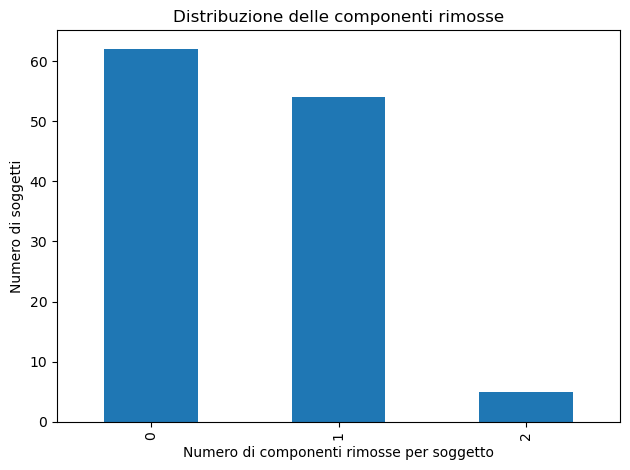

In [63]:
display(subject_summary_df)

print('Soggetti senza componenti rimosse:', int((subject_summary_df['n_removed'] == 0).sum()))
print('Soggetti con almeno una componente rimossa:', int((subject_summary_df['n_removed'] > 0).sum()))
print('Totale componenti rimosse:', int(subject_summary_df['n_removed'].sum()))
print('ICA non convergenti:', int((~subject_summary_df['ica_converged']).sum()))

removal_distribution = subject_summary_df['n_removed'].value_counts().sort_index()
display(removal_distribution.rename_axis('n_removed').reset_index(name='n_subjects'))

removal_distribution.plot(
    kind='bar',
    xlabel='Numero di componenti rimosse per soggetto',
    ylabel='Numero di soggetti',
    title='Distribuzione delle componenti rimosse',
)
plt.tight_layout()
plt.show()

### Casi da controllare

In [64]:
cases_to_check = subject_summary_df.loc[
    (subject_summary_df['n_removed'] >= 4)
    | (~subject_summary_df['ica_converged'])
]

if cases_to_check.empty:
    print('Nessun caso anomalo secondo i criteri impostati.')
else:
    print('Soggetti da controllare:')
    display(cases_to_check)

Nessun caso anomalo secondo i criteri impostati.


## 11. Confronto qualitativo prima/dopo

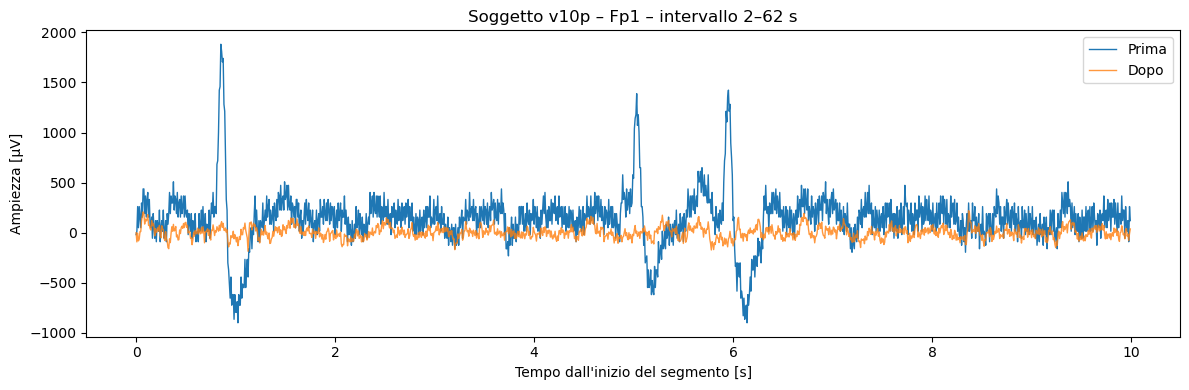

In [65]:
SUBJECT_FOR_COMPARISON = subject_ids[0]
CHANNEL_TO_PLOT = "Fp1"
SECONDS_TO_PLOT = 10

subject_before_full = df.loc[
    df[ID_COLUMN] == SUBJECT_FOR_COMPARISON
].copy()

start_sample = int(round(START_OFFSET_SEC * SFREQ))
stop_sample = start_sample + int(round(COMMON_DURATION_SEC * SFREQ))

before = subject_before_full.iloc[start_sample:stop_sample].reset_index(drop=True)
after = clean_df.loc[
    clean_df[ID_COLUMN] == SUBJECT_FOR_COMPARISON
].copy().reset_index(drop=True)

n_samples_plot = min(int(SECONDS_TO_PLOT * SFREQ), len(before), len(after))
time = np.arange(n_samples_plot) / SFREQ

plt.figure(figsize=(12, 4))
plt.plot(time, before[CHANNEL_TO_PLOT].iloc[:n_samples_plot], label="Prima", linewidth=1)
plt.plot(time, after[CHANNEL_TO_PLOT].iloc[:n_samples_plot], label="Dopo", linewidth=1, alpha=0.8)
plt.xlabel("Tempo dall'inizio del segmento [s]")
plt.ylabel("Ampiezza [µV]")
plt.title(
    f"Soggetto {SUBJECT_FOR_COMPARISON} – {CHANNEL_TO_PLOT} – "
    f"intervallo {START_OFFSET_SEC:.0f}–{START_OFFSET_SEC + COMMON_DURATION_SEC:.0f} s"
)
plt.legend()
plt.tight_layout()
plt.show()
